Hola **Aron**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

**Tip**: Para dejar un notebook mucho mejor presentado y más claro te recomiendo siempre al inicio del mismo en una celda markdown dejar un título y una breve introducción del proyecto para que el contexto sea claro desde el inicio
</div>

In [1]:
import pandas as pd
import datetime as dt
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Hypothesis = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')
Hypothesis

,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5



# Calcular ICE: (Impact * Confidence) / Effort

In [3]:
Hypothesis['ICE'] = (Hypothesis['Impact'] * Hypothesis['Confidence']) / Hypothesis['Effort']


# Calcular RICE: (Reach * Impact * Confidence) / Effort

In [4]:
Hypothesis['RICE'] = (Hypothesis['Reach'] * Hypothesis['Impact'] * Hypothesis['Confidence']) / Hypothesis['Effort']

In [5]:
print(Hypothesis[['Hypothesis', 'ICE']].sort_values(by='ICE', ascending=False))


                                          Hypothesis        ICE
8  Launch a promotion that gives users discounts ...  16.200000
0  Add two new channels for attracting traffic. T...  13.333333
7  Add a subscription form to all the main pages....  11.200000
6  Show banners with current offers and sales on ...   8.000000
2  Add product recommendation blocks to the store...   7.000000
1  Launch your own delivery service. This will sh...   2.000000
5  Add a customer review page. This will increase...   1.333333
3  Change the category structure. This will incre...   1.125000
4  Change the background color on the main page. ...   1.000000


In [6]:
print(Hypothesis[['Hypothesis', 'RICE']].sort_values(by='RICE', ascending=False))

                                          Hypothesis   RICE
7  Add a subscription form to all the main pages....  112.0
2  Add product recommendation blocks to the store...   56.0
0  Add two new channels for attracting traffic. T...   40.0
6  Show banners with current offers and sales on ...   40.0
8  Launch a promotion that gives users discounts ...   16.2
3  Change the category structure. This will incre...    9.0
1  Launch your own delivery service. This will sh...    4.0
5  Add a customer review page. This will increase...    4.0
4  Change the background color on the main page. ...    3.0


# conclusion parte 1

A primera vista en RISE la hipotesis 8 es la de mayor prioridad  mientras que en ICE tenemos probablemente 3 que sobresalen que son las 8, 0 y 7 dando por la de mayor prioridad la numero 7 que es la de agregar un metodo de suscripcion a las paginas principales

In [7]:
# grafico para explicar las diferencias

In [8]:
Hypothesis['ID'] = range(1, len(Hypothesis) + 1)

In [9]:
df_sorted = Hypothesis.sort_values(by='RICE', ascending=False)

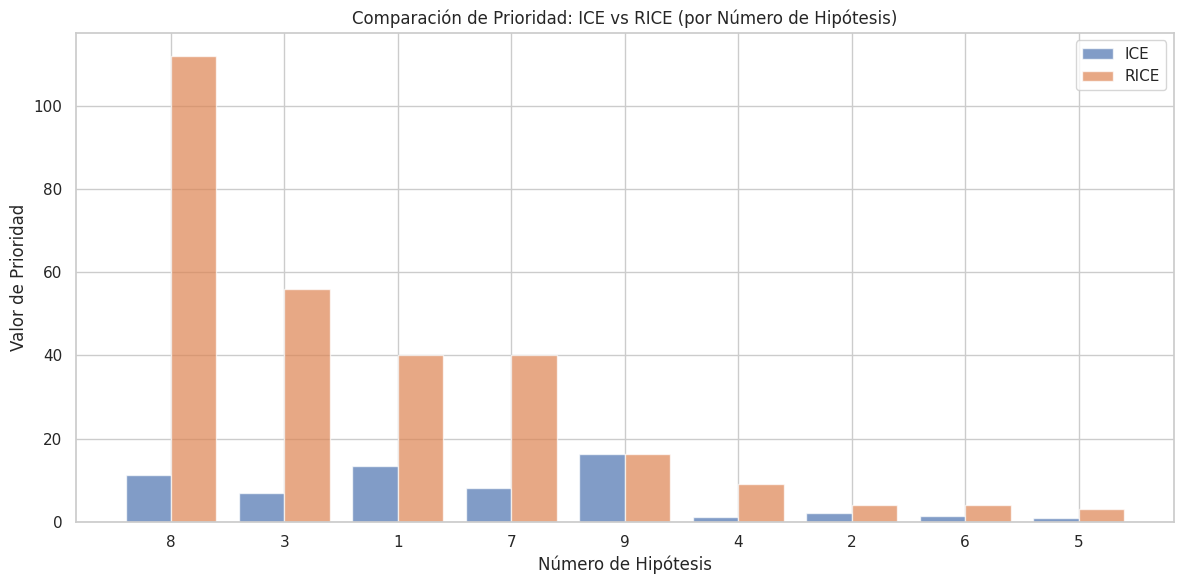

In [10]:
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

bar_width = 0.4
x = range(len(df_sorted))
plt.bar(x, df_sorted['ICE'], width=bar_width, label='ICE', alpha=0.7)
plt.bar([i + bar_width for i in x], df_sorted['RICE'], width=bar_width, label='RICE', alpha=0.7)
plt.xticks([i + bar_width / 2 for i in x], df_sorted['ID'], rotation=0)
plt.xlabel('Número de Hipótesis')
plt.ylabel('Valor de Prioridad')
plt.title('Comparación de Prioridad: ICE vs RICE (por Número de Hipótesis)')
plt.legend()
plt.tight_layout()

plt.show()

en la siguiente grafica podemos notar una gran diferencia en general en el RICE ante el ICE en practicamente todas las hipotesis solo en la 9 son practicamente similares. pero en las demas el rice es superior a las otras hipotesis esto podria estar sucendiendo o verse reflejado por el factor Reach o el alcance a los individuos en dichas hipotesis

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy buen trabajo con el cálculo para la priorización con los diferentes frameworks! Para explicar mejor las diferencias podrías apoyarte de alguna gráfica que muestre cómo cambia cada hipótesis con los diferentes frameworks
</div>

# parte 2

In [11]:
orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')


In [12]:
orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])


In [13]:
print("Duplicados en orders:", orders.duplicated().sum())
print("Duplicados en visits:", visits.duplicated().sum())

Duplicados en orders: 0
Duplicados en visits: 0


In [14]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [15]:
duplicated_visitors = orders.groupby('visitorId')['group'].nunique()
dual_group_visitors = duplicated_visitors[duplicated_visitors > 1]
print(f"Número de usuarios en ambos grupos: {dual_group_visitors.shape[0]}")

Número de usuarios en ambos grupos: 58


In [16]:
visitors_to_remove = orders[orders['visitorId'].isin(dual_group_visitors.index)]['visitorId'].unique()
orders = orders[~orders['visitorId'].isin(visitors_to_remove)]

Buscamos eliminar visitantes dublicados o que esten en ambos dataframe para evitar errores

In [17]:
cumulative_revenue = (
    orders.groupby(['date', 'group'])['revenue']
    .sum()
    .reset_index()
    .sort_values(by='date')
)

In [18]:
cumulative_revenue['cumulative_revenue'] = cumulative_revenue.groupby('group')['revenue'].cumsum()

Buscamos obtener los ingresos acumulados de ambos grupos 

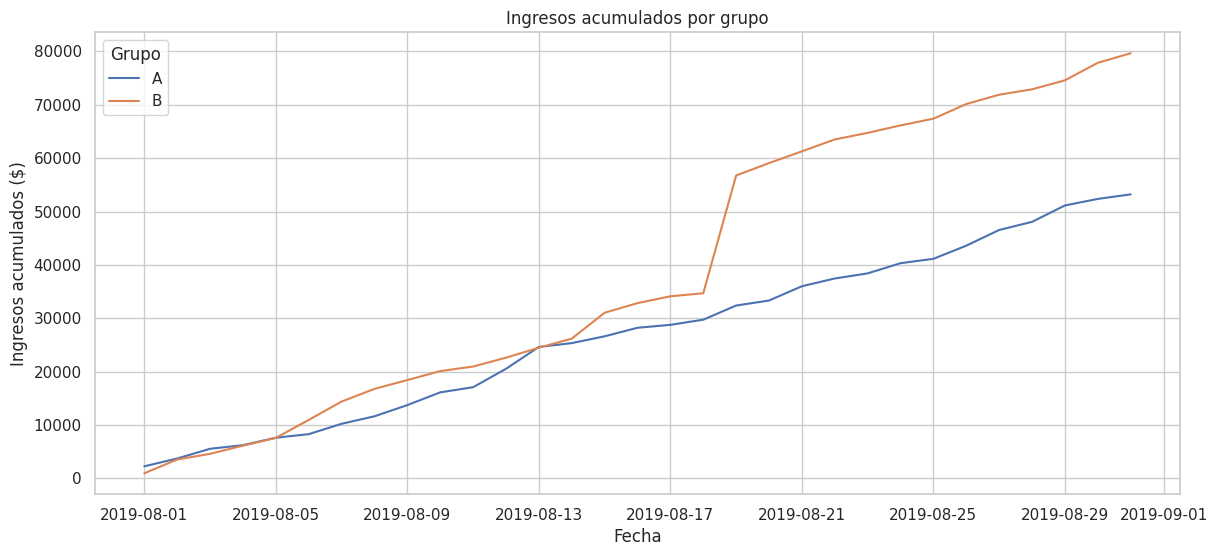

In [19]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=cumulative_revenue, x='date', y='cumulative_revenue', hue='group')
plt.title("Ingresos acumulados por grupo")
plt.xlabel("Fecha")
plt.ylabel("Ingresos acumulados ($)")
plt.legend(title="Grupo")
plt.show()

In [20]:
orders_count = (
    orders.groupby(['date', 'group'])['transactionId']
    .count()
    .reset_index()
    .rename(columns={'transactionId': 'orders_count'})
)

In [21]:
orders_count['cumulative_orders'] = orders_count.groupby('group')['orders_count'].cumsum()
orders_count['cumulative_revenue'] = cumulative_revenue['cumulative_revenue']

In [22]:
orders_count['avg_order_value'] = orders_count['cumulative_revenue'] / orders_count['cumulative_orders']

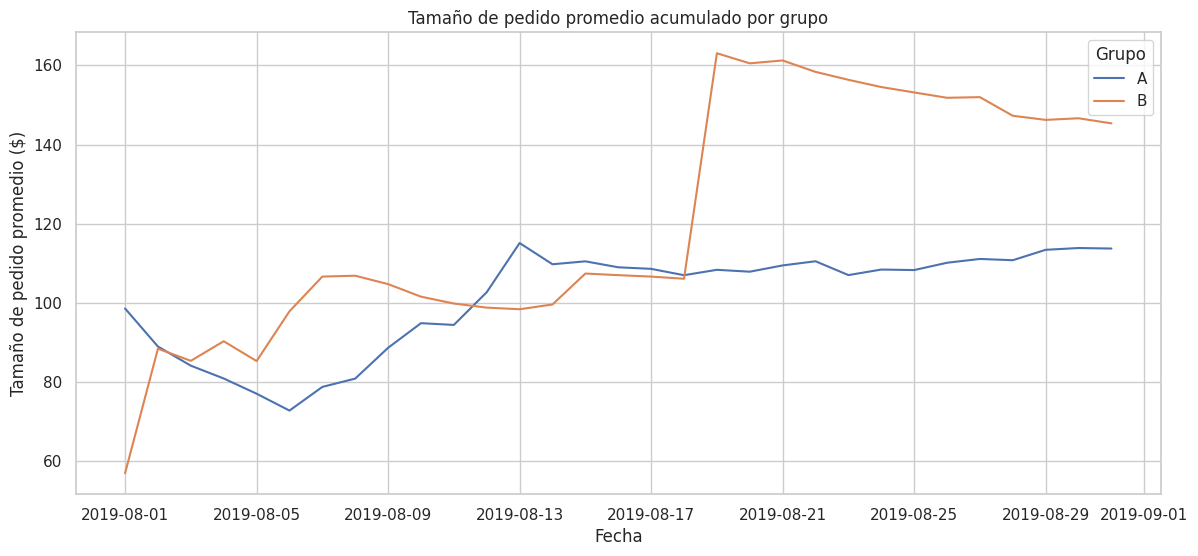

In [23]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=orders_count, x='date', y='avg_order_value', hue='group')
plt.title("Tamaño de pedido promedio acumulado por grupo")
plt.xlabel("Fecha")
plt.ylabel("Tamaño de pedido promedio ($)")
plt.legend(title="Grupo")
plt.show()

el grupo B tiene en promedioun tamaño acumulado mayor comparandolo con el A

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Buen trabajo, la visualización deja ver la diferencia claramente por cada grupo
</div>

# Calcular ingresos y número de pedidos por fecha y grupo

In [24]:
daily_revenue = orders.groupby(['date', 'group']).agg({
    'revenue': 'sum',
    'transactionId': 'nunique'
}).rename(columns={'transactionId': 'orders'}).reset_index()


In [25]:
daily_revenue['cum_revenue'] = daily_revenue.groupby('group')['revenue'].cumsum()
daily_revenue['cum_orders'] = daily_revenue.groupby('group')['orders'].cumsum()

In [26]:
daily_revenue['avg_order_value'] = daily_revenue['cum_revenue'] / daily_revenue['cum_orders']

# Separamos en grupos A y B

In [27]:
group_A = daily_revenue[daily_revenue['group'] == 'A']
group_B = daily_revenue[daily_revenue['group'] == 'B']

In [28]:
merged = pd.merge(group_A[['date', 'avg_order_value']], 
                  group_B[['date', 'avg_order_value']], 
                  on='date', suffixes=('_A', '_B'))

Calculamos las diferencias entre los grupos A y B

In [29]:
merged['relative_diff'] = (merged['avg_order_value_B'] - merged['avg_order_value_A']) / merged['avg_order_value_A']

Calculando diferencia semanalmente en ambos grupos A y B

In [30]:
merged['week'] = merged['date'].dt.to_period('W').astype(str)

In [31]:
weekly_diff = merged.groupby('week')['relative_diff'].mean().reset_index()

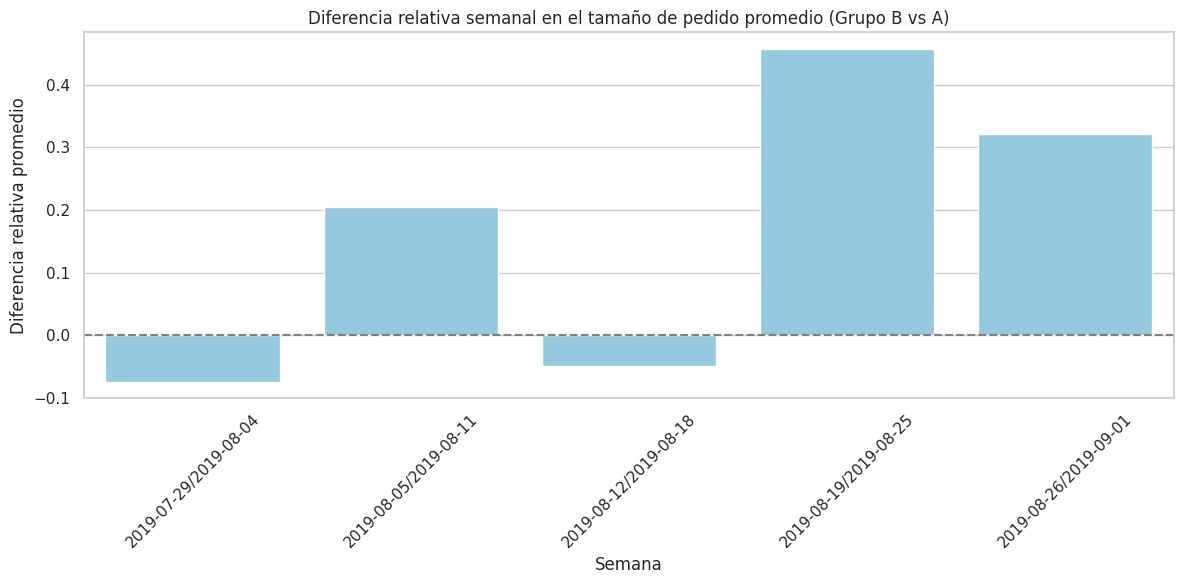

In [32]:
plt.figure(figsize=(12, 6))
sns.barplot(x='week', y='relative_diff', data=weekly_diff, color='skyblue')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Diferencia relativa semanal en el tamaño de pedido promedio (Grupo B vs A)')
plt.xlabel('Semana')
plt.ylabel('Diferencia relativa promedio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

la diferencia semanal de ambos grupos es significativa a afavor del grupo b

# tasa de conversion

In [33]:
orders_per_day = orders.groupby(['date', 'group'])['transactionId'].nunique().reset_index()
orders_per_day = orders_per_day.rename(columns={'transactionId': 'orders'})

In [34]:
conversion = pd.merge(visits, orders_per_day, on=['date', 'group'], how='left')
conversion['orders'] = conversion['orders'].fillna(0)

In [35]:
conversion['conversion_rate'] = conversion['orders'] / conversion['visits']

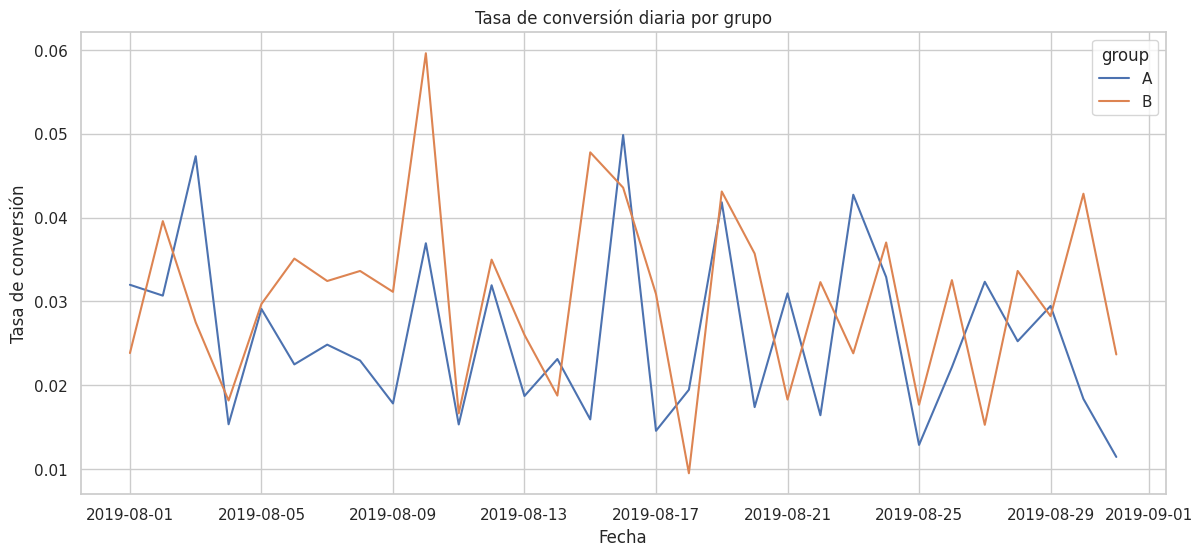

In [36]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=conversion, x='date', y='conversion_rate', hue='group')
plt.title('Tasa de conversión diaria por grupo')
plt.xlabel('Fecha')
plt.ylabel('Tasa de conversión')
plt.grid(True)
plt.show()


En este grafico podemos notar picos de conversion mucho mayores del grupo B mientras que el grupo A a tenido sus picos pero sin superar por mucho al grupo B ademas de que esta teniendo una decaida o baja mayor ante el grupo B

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien trabajadas y analizadas las gráficas, es importante en pruebas AB siempre poder comparar de manera visual los cambios entre cada grupo
</div>

# numero de pedidos por usuarios

In [37]:
orders_per_user = orders.groupby('visitorId')['transactionId'].nunique().reset_index()
orders_per_user.columns = ['visitorId', 'order_count']

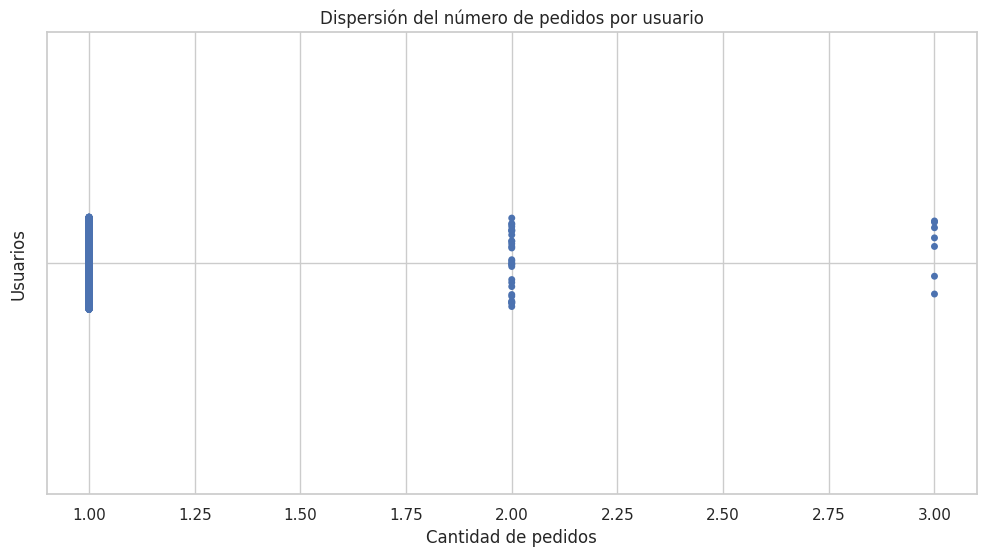

In [38]:
plt.figure(figsize=(12, 6))
sns.stripplot(data=orders_per_user, x='order_count', jitter=True)
plt.title('Dispersión del número de pedidos por usuario')
plt.xlabel('Cantidad de pedidos')
plt.ylabel('Usuarios')
plt.grid(True)
plt.show()

este grafico me indica que practicamente la mayoria de usuarios solo hace 1 pedido unicamente y son pocos los usuarios que hacen 2 o 3 pedidos como maximo

# percentiles

In [39]:
pedidos95 = np.percentile(orders_per_user['order_count'], 95)
pedidos99 = np.percentile(orders_per_user['order_count'], 99)

print(f"Percentil 95: {pedidos95}")
print(f"Percentil 99: {pedidos99}")

Percentil 95: 1.0
Percentil 99: 2.0


In [40]:
anomalous_users = orders_per_user[orders_per_user['order_count'] > pedidos99]
print(f"Número de usuarios con comportamiento anómalo: {anomalous_users.shape[0]}")
print(anomalous_users.sort_values(by='order_count', ascending=False))

Número de usuarios con comportamiento anómalo: 7
      visitorId  order_count
55    249864742            3
138   611059232            3
478  2108163459            3
632  2742574263            3
687  2988190573            3
890  3908431265            3
908  3967698036            3


por lo que entiendo es que el percentil 99 y 95 tenemos muy pocos usuarios lo cual lo hace poco comun encontrar usuarios con 3 o mas pedidos

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

La variable p99 no ha sido declarada antes por lo que da este error de ejecución, recuerda que cuando compartes un notebook todas las variables se borran y el notebook se ejecuta de arriba hacia abajo por lo que si esa variable no se define antes causará errores
</div>

# precio de productos

In [41]:
print(orders['revenue'].describe())

count     1016.000000
mean       130.770866
std        648.079810
min          5.000000
25%         20.775000
50%         50.100000
75%        126.950000
max      19920.400000
Name: revenue, dtype: float64


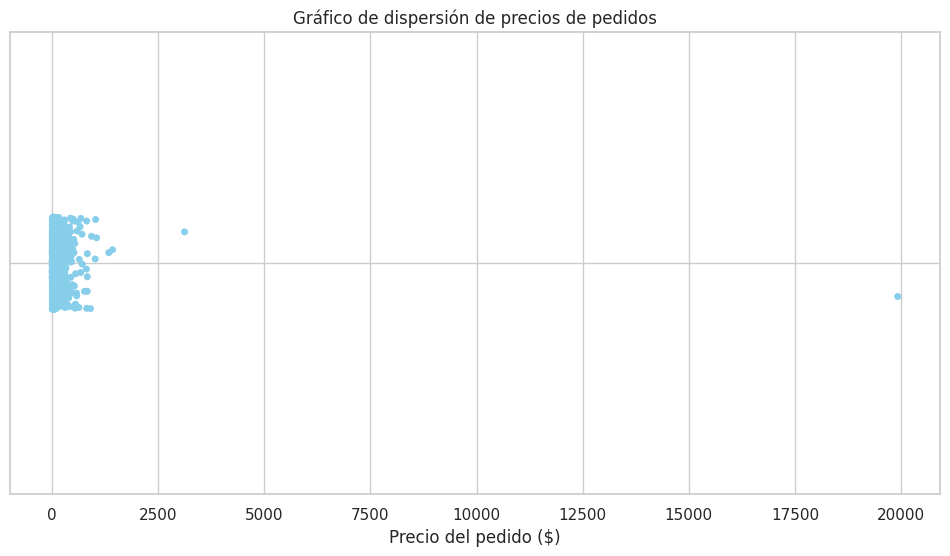

In [42]:
plt.figure(figsize=(12, 6))
sns.stripplot(x=orders['revenue'], jitter=True, color='skyblue')
plt.title('Gráfico de dispersión de precios de pedidos')
plt.xlabel('Precio del pedido ($)')
plt.grid(True)
plt.show()

hay un par de pedidos que son una anomalia o inusuales con valores muy por encima del promedio de pedidos normalmente en la pagina

In [43]:
# percentil revenue

In [44]:
prevenue95 = np.percentile(orders['revenue'], 95)
prevenue99 = np.percentile(orders['revenue'], 99)

print(f"Percentil 95 del precio del pedido: ${prevenue95:.2f}")
print(f"Percentil 99 del precio del pedido: ${prevenue99:.2f}")

Percentil 95 del precio del pedido: $414.27
Percentil 99 del precio del pedido: $830.30


#anomalia

In [45]:
anomaly_threshold = prevenue99
anomalous_orders = orders[orders['revenue'] > anomaly_threshold]

print(f"Número de pedidos anómalos (precio > {anomaly_threshold:.2f}): {len(anomalous_orders)}")
print(anomalous_orders[['transactionId', 'revenue']].sort_values(by='revenue', ascending=False).head())

Número de pedidos anómalos (precio > 830.30): 9
      transactionId  revenue
425       590470918  19920.4
1196     3936777065   3120.1
1136      666610489   1425.8
744      3668308183   1335.6
743      3603576309   1050.0


tenemos varios registros que superan el percentil 99 que podria indicar errores de captura o pedidos muy fuera de los comun

# significancia en la conversion

vamos a eliminar los ooutliners o pedidos atipicos fuera de nuestros percentiles

In [46]:
revenue_95 = orders['revenue'].quantile(0.95)

In [47]:
orders_by_user = orders.groupby('visitorId').agg({'transactionId': 'nunique'}).reset_index()
orders_by_user.columns = ['userId', 'orders']
orders_95 = orders_by_user['orders'].quantile(0.95)

In [48]:
outlier_users = orders_by_user[orders_by_user['orders'] > orders_95]['userId']

In [49]:
filtered_orders = orders[
    (orders['revenue'] <= revenue_95) &
    (~orders['visitorId'].isin(outlier_users))
]

ahora filtramos con los datos que teniamos ya eliminando los outliners

In [50]:
orders_per_day = filtered_orders.groupby(['date', 'group'])['transactionId'].nunique().reset_index()
orders_per_day = orders_per_day.rename(columns={'transactionId': 'orders'})

In [51]:
conversion = pd.merge(visits, orders_per_day, on=['date', 'group'], how='left')
conversion['orders'] = conversion['orders'].fillna(0)
conversion['conversion_rate'] = conversion['orders'] / conversion['visits']

conversiones por grupo

In [52]:
conv_A = conversion[conversion['group'] == 'A']['conversion_rate']
conv_B = conversion[conversion['group'] == 'B']['conversion_rate']

In [53]:
stat_conv, p_conv = stats.mannwhitneyu(conv_A, conv_B, alternative='two-sided')
print(f"Valor p (conversión): {p_conv:.5f}")
if p_conv < 0.05:
    print("Conversión: diferencia estadísticamente significativa entre grupos.")
else:
    print("Conversión: NO hay diferencia estadísticamente significativa.")

Valor p (conversión): 0.04335
Conversión: diferencia estadísticamente significativa entre grupos.


como anteriormente vimos el grupo b sigue teniendo ventaja sobre el grupo A probablemente este utilizando mejor las herramientas de alcance consiguiendo mas interacciones o ventas atraves de duchas estrategias

# encuentra las significancia estadistica 

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

La segunda parte de la significancia estadística se debe realizar filtrando los datos para quitar los outliers que se pudo identificar en el paso del análisis de los percentiles 
</div>

Conversiones por grupo pero en la ganancia por grupo

In [55]:
revenue_A = filtered_orders[filtered_orders['group'] == 'A']['revenue']
revenue_B = filtered_orders[filtered_orders['group'] == 'B']['revenue']

In [56]:
stat_rev, p_rev = stats.mannwhitneyu(revenue_A, revenue_B, alternative='two-sided')
print(f"Valor p (tamaño de pedido): {p_rev:.5f}")
if p_rev < 0.05:
    print("→ Tamaño de pedido: diferencia estadísticamente significativa entre grupos.")
else:
    print("Tamaño de pedido: NO hay diferencia estadísticamente significativa.")

Valor p (tamaño de pedido): 0.77119
Tamaño de pedido: NO hay diferencia estadísticamente significativa.


curiosamente las ganancias o las ganancias por grupo son equiparables o no crean una ventaja tan grande como deberia haber tenido dada la ventaja en alcance que tiene el grupo b

# Toma una decisión basada en los resultados de la prueba.

In [57]:
if p_conv < 0.05 and p_rev < 0.05:
    print("Decisión: Parar la prueba. Grupo B es líder claro en conversión y tamaño de pedido.")
elif p_conv > 0.05 and p_rev > 0.05:
    print("Decisión: Parar la prueba. No hay diferencia significativa entre los grupos.")
else:
    print("Decisión: Continuar la prueba. Aún no hay evidencia suficiente en ambas métricas.")


Decisión: Continuar la prueba. Aún no hay evidencia suficiente en ambas métricas.


<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Esta parte de la decisión debería ser en base a tu criterio de lo que pudiste analizar a lo largo del notebook. Deberías tener una sección de conclusiones finales donde resumas los hallazgos más importantes de todo el notebook incluyendo la parte sobre la decisión de la prueba.
</div>

# Conclusiones

Primero que nada la decision seria seguir la prueba ya que aun no hay metricas suficientes para darla por finalizada ya que es verdad que el grupo b tiene ventaja en el Rice o el alcance pero en el revenue o las ganancia que se generaron por grupo son muy similares asi que aun no hay suficiente evidencia para reconocer que grupo tiene una mejor estrategia para atraer o concretar mas ganancias. ya que unas tienen ventas en algunas metricas o parametros y otras ventajas en otras diferentes.